In [ ]:
!pip install pandas matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All librs imported succesfully")

All librs imported succesfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/CodTech_Internship/matches.csv')

print("Data loaded successfully!")
print("Shape:", df_raw.shape)

Data loaded successfully!
Shape: (1095, 20)


In [ ]:
# Work on a copy
df = df_raw.copy()

# Drop 'method' column (98% missing)
df.drop(columns=['method'], inplace=True)

# Fix missing values
df['city'] = df['city'].fillna('Unknown')
df['result_margin'] = df['result_margin'].fillna(0)
df['target_runs'] = df['target_runs'].fillna(0)
df['target_overs'] = df['target_overs'].fillna(0)
df['player_of_match'] = df['player_of_match'].fillna('Unknown')

print("Cleaning done!")
print("Missing values remaining:", df.isnull().sum().sum())
print("Shape:", df.shape)

Cleaning done!
Missing values remaining: 5
Shape: (1095, 19)


In [ ]:
# Feature 1: Did the toss winner also win the match?
df['toss_win_match_win'] = (df['toss_winner'] == df['winner']).astype(int)

print("Feature 1 done!")
print(df['toss_win_match_win'].value_counts())

Feature 1 done!
toss_win_match_win
1    554
0    541
Name: count, dtype: int64


In [ ]:
# Feature 2: Was it a high margin win?
df['high_margin_win'] = (
    (df['result'] == 'runs') & (df['result_margin'] > 50) |
    (df['result'] == 'wickets') & (df['result_margin'] > 7)
).astype(int)

print("Feature 2 done!")
print(df['high_margin_win'].value_counts())

Feature 2 done!
high_margin_win
0    862
1    233
Name: count, dtype: int64


In [ ]:
# Feature 3: Which era of IPL did the match belong to?
df['ipl_era'] = pd.cut(
    df['season'],
    bins=[2007, 2013, 2017, 2022],
    labels=['Early Era (2008-2013)', 'Middle Era (2014-2017)', 'Modern Era (2018-2022)']
)

print("Feature 3 done!")
print(df['ipl_era'].value_counts())

TypeError: '<' not supported between instances of 'int' and 'str'

In [ ]:
# First check what season column looks like
print(df['season'].dtype)
print(df['season'].unique())

object
['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']


In [ ]:
# Extract just the first 4 characters (the year) and convert to integer
df['season_year'] = df['season'].str[:4].astype(int)

print("Season fixed!")
print(df['season_year'].unique())

Season fixed!
[2007 2009 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]


In [ ]:
# Feature 3: IPL Era using the fixed season_year column
df['ipl_era'] = pd.cut(
    df['season_year'],
    bins=[2006, 2013, 2018, 2025],
    labels=['Early Era (2007-2013)', 'Middle Era (2014-2018)', 'Modern Era (2019-2024)']
)

print("Feature 3 done!")
print(df['ipl_era'].value_counts())

Feature 3 done!
ipl_era
Modern Era (2019-2024)    399
Early Era (2007-2013)     398
Middle Era (2014-2018)    298
Name: count, dtype: int64


In [ ]:
# Feature 4: Did the team batting first win the match?
df['bat_first_won'] = (
    (df['toss_decision'] == 'bat') & (df['toss_winner'] == df['winner']) |
    (df['toss_decision'] == 'field') & (df['toss_winner'] != df['winner'])
).astype(int)

print("Feature 4 done!")
print(df['bat_first_won'].value_counts())


Feature 4 done!
bat_first_won
0    591
1    504
Name: count, dtype: int64


In [ ]:
# Preview all engineered features together
print("New features added to dataset:")
print(df[['season', 'toss_winner', 'winner', 'result', 'result_margin',
          'toss_win_match_win', 'high_margin_win', 'ipl_era', 'bat_first_won']].head(10))

print("\nDataset shape after feature engineering:", df.shape)


New features added to dataset:
    season                  toss_winner                       winner   result  \
0  2007/08  Royal Challengers Bangalore        Kolkata Knight Riders     runs   
1  2007/08          Chennai Super Kings          Chennai Super Kings     runs   
2  2007/08             Rajasthan Royals             Delhi Daredevils  wickets   
3  2007/08               Mumbai Indians  Royal Challengers Bangalore  wickets   
4  2007/08              Deccan Chargers        Kolkata Knight Riders  wickets   
5  2007/08              Kings XI Punjab             Rajasthan Royals  wickets   
6  2007/08              Deccan Chargers             Delhi Daredevils  wickets   
7  2007/08               Mumbai Indians          Chennai Super Kings     runs   
8  2007/08             Rajasthan Royals             Rajasthan Royals  wickets   
9  2007/08               Mumbai Indians              Kings XI Punjab     runs   

   result_margin  toss_win_match_win  high_margin_win                ipl_era 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Define column types
numerical_cols   = ['result_margin', 'season_year', 'toss_win_match_win',
                    'high_margin_win', 'bat_first_won']

categorical_cols = ['toss_decision', 'venue', 'city']

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['result_margin', 'season_year', 'toss_win_match_win', 'high_margin_win', 'bat_first_won']
Categorical columns: ['toss_decision', 'venue', 'city']


In [ ]:
# Pipeline for numerical columns
# Step 1: Fill any missing values with median
# Step 2: Scale all numbers to same range
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline for categorical columns
# Step 1: Fill any missing values with most common value
# Step 2: Convert text categories to 0/1 columns
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline,   numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("✅ Pipeline built successfully!")

✅ Pipeline built successfully!


In [ ]:
# Define features and target variable
X = df[numerical_cols + categorical_cols]
y = df['winner']

# Split data 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply pipeline
# fit_transform = learn from training data AND transform it
# transform = only transform test data (using what it learned)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("✅ Pipeline applied successfully!")
print(f"Training set shape : {X_train_processed.shape}")
print(f"Test set shape     : {X_test_processed.shape}")

✅ Pipeline applied successfully!
Training set shape : (876, 102)
Test set shape     : (219, 102)


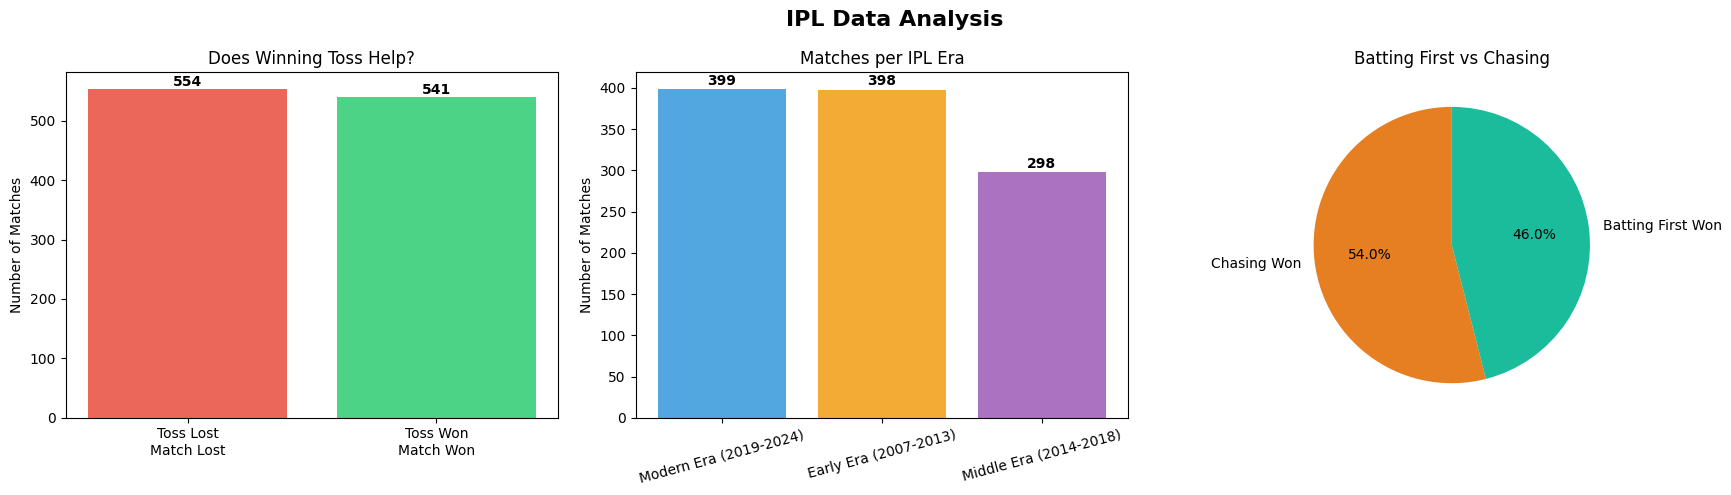

✅ Charts saved to Google Drive!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('IPL Data Analysis', fontsize=16, fontweight='bold')

# Chart 1: Toss Win vs Match Win
toss_counts = df['toss_win_match_win'].value_counts()
axes[0].bar(['Toss Lost\nMatch Lost', 'Toss Won\nMatch Won'],
            toss_counts.values, color=['#e74c3c', '#2ecc71'], alpha=0.85)
axes[0].set_title('Does Winning Toss Help?')
axes[0].set_ylabel('Number of Matches')
for i, v in enumerate(toss_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Chart 2: IPL Era Distribution
era_counts = df['ipl_era'].value_counts()
axes[1].bar(era_counts.index, era_counts.values,
            color=['#3498db', '#f39c12', '#9b59b6'], alpha=0.85)
axes[1].set_title('Matches per IPL Era')
axes[1].set_ylabel('Number of Matches')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(era_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Chart 3: Bat First vs Chase
bat_counts = df['bat_first_won'].value_counts()
axes[2].pie(bat_counts.values,
            labels=['Chasing Won', 'Batting First Won'],
            autopct='%1.1f%%',
            colors=['#e67e22', '#1abc9c'],
            startangle=90)
axes[2].set_title('Batting First vs Chasing')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CodTech_Internship/ipl_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved to Google Drive!")

In [ ]:
# Save cleaned dataset to Google Drive
df.to_csv('/content/drive/MyDrive/CodTech_Internship/ipl_cleaned.csv', index=False)

print("✅ Cleaned data saved!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print()
print("=" * 40)
print("   🎉 TASK 1 COMPLETE!")
print("   ETL Pipeline successfully built")
print("   on IPL Cricket Dataset")
print("=" * 40)

✅ Cleaned data saved!
   Rows    : 1095
   Columns : 24

   🎉 TASK 1 COMPLETE!
   ETL Pipeline successfully built
   on IPL Cricket Dataset
